# NB02: Exploratory Data Analysis

Understand the distribution of crash counts, check for overdispersion,
examine predictor distributions, and identify any collinearity concerns.

**Reads:** `data/processed/nb_model_ready.csv` (produced by NB01)
**Writes:** EDA plots to `outputs/diagnostic_plots/eda_*.png`

## Inputs / Outputs

| Direction | File | Description |
|-----------|------|-------------|
| Input | `data/processed/nb_model_ready.csv` | Clean joined dataset from NB01 |
| Output | `outputs/diagnostic_plots/eda_crash_distribution.png` | Crash count histogram + summary stats |
| Output | `outputs/diagnostic_plots/eda_mean_variance.png` | Mean vs variance per stratum (overdispersion check) |
| Output | `outputs/diagnostic_plots/eda_correlation.png` | Predictor correlation matrix |
| Output | `outputs/diagnostic_plots/eda_crash_by_category.png` | Crash counts by dim_type and dim_priority |
| Output | `outputs/diagnostic_plots/eda_cv_score.png` | CV score distribution (labelled intersections only) |

In [ ]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

# ROOT is one level up from pipeline/ — mirrors the pattern in NB01
ROOT      = Path("..").resolve()
OUTPUTS   = ROOT / "outputs"               # final deliverables + diagnostic plots
PROCESSED = ROOT / "data" / "processed"   # intermediate files from NB01
PLOTS     = OUTPUTS / "diagnostic_plots"
PLOTS.mkdir(parents=True, exist_ok=True)

# Load the prepared dataset — never read raw data files in this notebook
df = pd.read_csv(PROCESSED / "nb_model_ready.csv", dtype={"intersection_id": int})

print(f"Loaded nb_model_ready.csv: {len(df)} rows, {df.shape[1]} columns")
df.head()

## 1. Crash Count Distribution

Plot the empirical crash count distribution against a fitted Poisson baseline.
If the observed distribution has heavier tails (more zeros and high counts than
Poisson predicts), overdispersion is present and the Negative Binomial model is
justified over a simpler Poisson regression.

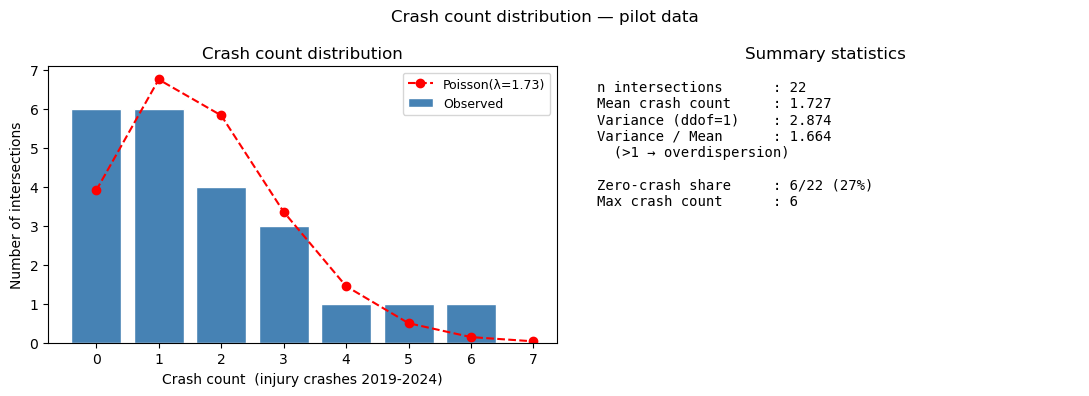

Overdispersion ratio (variance/mean): 1.664


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: bar chart of observed crash counts + expected Poisson counts overlaid.
# If the distribution has heavier tails than Poisson, NB is the right model.
ax = axes[0]
counts = df["crash_count"].value_counts().sort_index()
ax.bar(counts.index, counts.values, color="steelblue", edgecolor="white",
       label="Observed")

mu = df["crash_count"].mean()
k_range = np.arange(0, counts.index.max() + 2)
poisson_expected = stats.poisson.pmf(k_range, mu) * len(df)
ax.plot(k_range, poisson_expected, "ro--", markersize=6,
        label=f"Poisson(λ={mu:.2f})")

ax.set_xlabel("Crash count  (injury crashes 2019-2024)")
ax.set_ylabel("Number of intersections")
ax.set_title("Crash count distribution")
ax.legend(fontsize=9)
ax.set_xticks(k_range)

# Right: text summary with overdispersion ratio
ax = axes[1]
ax.axis("off")
var_cc  = df["crash_count"].var(ddof=1)
ratio   = var_cc / mu
zero_n  = int((df["crash_count"] == 0).sum())
lines = [
    f"n intersections      : {len(df)}",
    f"Mean crash count     : {mu:.3f}",
    f"Variance (ddof=1)    : {var_cc:.3f}",
    f"Variance / Mean      : {ratio:.3f}",
    f"  (>1 → overdispersion)",
    "",
    f"Zero-crash share     : {zero_n}/{len(df)} ({zero_n/len(df):.0%})",
    f"Max crash count      : {int(df['crash_count'].max())}",
]
ax.text(0.05, 0.95, "\n".join(lines), transform=ax.transAxes,
        va="top", fontfamily="monospace", fontsize=10)
ax.set_title("Summary statistics")

plt.suptitle("Crash count distribution — pilot data", fontsize=12)
plt.tight_layout()
plt.savefig(PLOTS / "eda_crash_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Overdispersion ratio (variance/mean): {ratio:.3f}")

## 2. Overdispersion Check by Stratum

If variance exceeds the mean within each stratum, the Negative Binomial model
is preferred over Poisson. Grouped bars show mean (blue) vs variance (red) per
category — if red consistently exceeds blue, overdispersion is real.

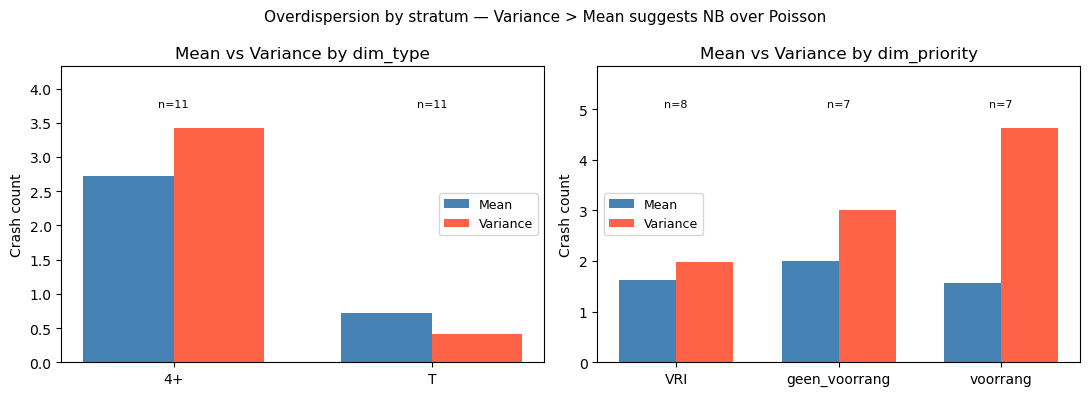

In [5]:
# Reconstruct category labels from dummies so we can group by them
df_cat = df.copy()
df_cat["dim_type"] = np.where(df_cat["dim_type_4p"] == 1, "4+", "T")
df_cat["dim_priority"] = np.where(
    df_cat["dim_priority_VRI"] == 1, "VRI",
    np.where(df_cat["dim_priority_voorrang"] == 1, "voorrang", "geen_voorrang")
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col in zip(axes, ["dim_type", "dim_priority"]):
    grp = df_cat.groupby(col)["crash_count"].agg(["mean", "var", "count"])
    grp.columns = ["Mean", "Variance", "n"]

    x = np.arange(len(grp))
    w = 0.35
    ax.bar(x - w / 2, grp["Mean"],     w, label="Mean",     color="steelblue")
    ax.bar(x + w / 2, grp["Variance"], w, label="Variance", color="tomato")

    # Annotate bars with group size
    y_top = max(grp["Variance"].max(), grp["Mean"].max()) * 1.15
    for xi, (cat, row) in enumerate(grp.iterrows()):
        ax.text(xi, y_top * 0.98, f"n={int(row['n'])}", ha="center", va="top", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(grp.index)
    ax.set_ylabel("Crash count")
    ax.set_title(f"Mean vs Variance by {col}")
    ax.legend(fontsize=9)
    ax.set_ylim(0, y_top * 1.1)

plt.suptitle(
    "Overdispersion by stratum — Variance > Mean suggests NB over Poisson",
    fontsize=11,
)
plt.tight_layout()
plt.savefig(PLOTS / "eda_mean_variance.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Predictor Correlations

A correlation matrix across all continuous predictors and dummy variables.
Pairs with |r| > 0.7 warrant attention before model fitting — they inflate
standard errors and make coefficients hard to interpret.

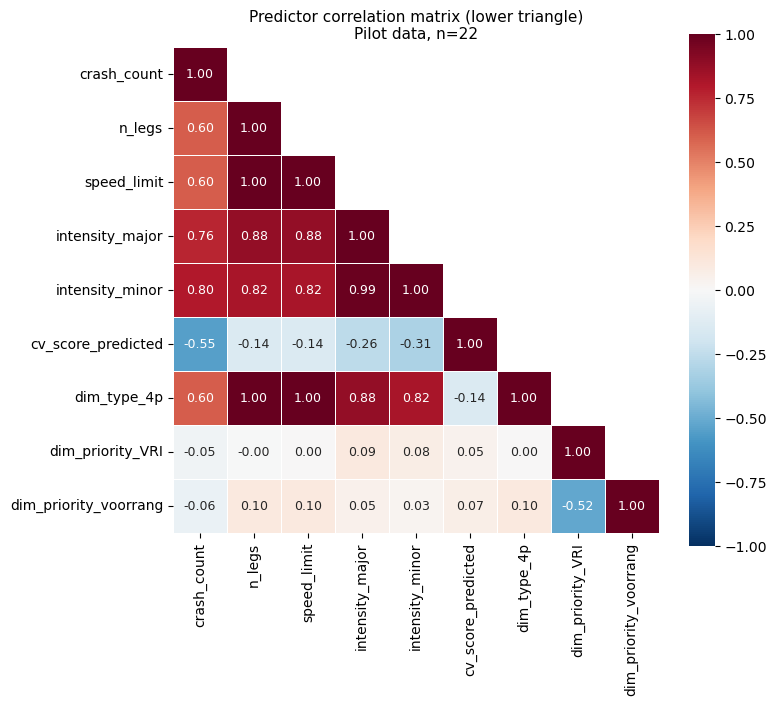

High-correlation pairs (|r| > 0.7) — potential collinearity:
  speed_limit × n_legs: r = 1.000
  intensity_major × crash_count: r = 0.759
  intensity_major × n_legs: r = 0.877
  intensity_major × speed_limit: r = 0.877
  intensity_minor × crash_count: r = 0.798
  intensity_minor × n_legs: r = 0.823
  intensity_minor × speed_limit: r = 0.823
  intensity_minor × intensity_major: r = 0.987
  dim_type_4p × n_legs: r = 1.000
  dim_type_4p × speed_limit: r = 1.000
  dim_type_4p × intensity_major: r = 0.877
  dim_type_4p × intensity_minor: r = 0.823


In [6]:
# Predictor correlation matrix — all continuous and dummy columns plus the outcome.
# Helps spot collinearity between predictors before model fitting.
pred_cols = [
    "crash_count",
    "n_legs", "speed_limit",
    "intensity_major", "intensity_minor",
    "cv_score_predicted",
    "dim_type_4p", "dim_priority_VRI", "dim_priority_voorrang",
]
corr = df[pred_cols].corr()

# Lower-triangle mask: hide upper triangle to avoid redundancy
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    corr, mask=mask,
    annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax,
    annot_kws={"size": 9},
)
ax.set_title(
    f"Predictor correlation matrix (lower triangle)\nPilot data, n={len(df)}",
    fontsize=11,
)
plt.tight_layout()
plt.savefig(PLOTS / "eda_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

# Flag any pairs with |r| > 0.7 as a collinearity concern
high = [
    (pred_cols[i], pred_cols[j], corr.iloc[i, j])
    for i in range(len(pred_cols))
    for j in range(i)
    if abs(corr.iloc[i, j]) > 0.7
]
if high:
    print("High-correlation pairs (|r| > 0.7) — potential collinearity:")
    for a, b, r in high:
        print(f"  {a} × {b}: r = {r:.3f}")
else:
    print("No predictor pairs with |r| > 0.7 — collinearity not a concern.")

## 4. Crash Counts by Intersection Type and Priority

Do T-intersections and 4+-arm intersections differ in crash counts? Does traffic
light control (VRI) or priority road status change the picture?

These are the categorical predictors encoded as dummies in Phase 4.

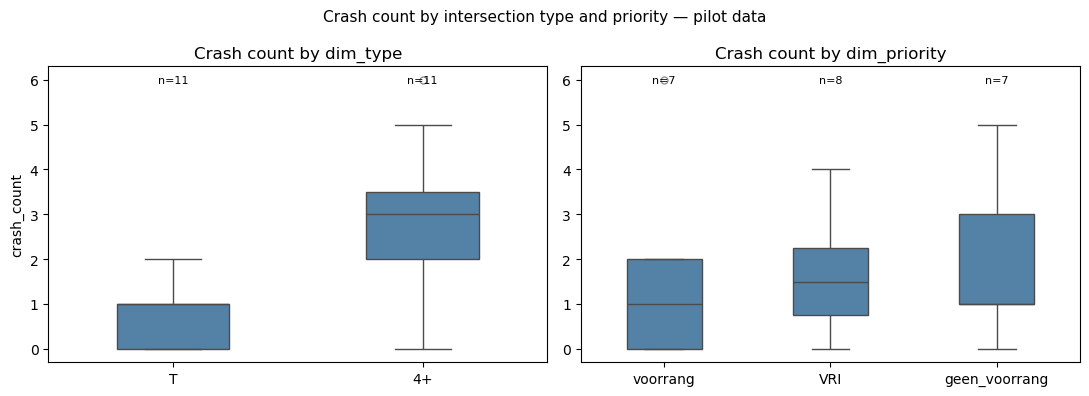


Mean crash count by dim_type:
           mean    std  count
dim_type                     
4+        2.727  1.849     11
T         0.727  0.647     11

Mean crash count by dim_priority:
                mean    std  count
dim_priority                      
VRI            1.625  1.408      8
geen_voorrang  2.000  1.732      7
voorrang       1.571  2.149      7


In [7]:
# Reconstruct readable category labels from the one-hot dummies for plotting.
# dim_type: T (3-arm) vs 4+ (4-or-more-arm)
# dim_priority: geen_voorrang / voorrang / VRI — derived by checking the dummies in order
df_cat = df.copy()
df_cat["dim_type"] = np.where(df_cat["dim_type_4p"] == 1, "4+", "T")
df_cat["dim_priority"] = np.where(
    df_cat["dim_priority_VRI"] == 1, "VRI",
    np.where(df_cat["dim_priority_voorrang"] == 1, "voorrang", "geen_voorrang")
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col in zip(axes, ["dim_type", "dim_priority"]):
    # Sort categories by mean crash count so the chart reads low→high
    order = df_cat.groupby(col)["crash_count"].mean().sort_values().index.tolist()
    sns.boxplot(
        data=df_cat, x=col, y="crash_count", order=order,
        color="steelblue", width=0.45,
        flierprops={"marker": "o", "markersize": 5, "alpha": 0.6},
        ax=ax,
    )
    # Annotate each group with its sample size
    y_top = ax.get_ylim()[1]
    for xi, cat in enumerate(order):
        n = (df_cat[col] == cat).sum()
        ax.text(xi, y_top * 0.97, f"n={n}", ha="center", va="top", fontsize=8)
    ax.set_title(f"Crash count by {col}")
    ax.set_xlabel("")
    ax.set_ylabel("crash_count" if ax is axes[0] else "")

plt.suptitle("Crash count by intersection type and priority — pilot data", fontsize=11)
plt.tight_layout()
plt.savefig(PLOTS / "eda_crash_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

# Print group means for reference
for col in ["dim_type", "dim_priority"]:
    print(f"\nMean crash count by {col}:")
    print(df_cat.groupby(col)["crash_count"].agg(["mean", "std", "count"]).round(3).to_string())

## 5. CV Score Distribution

Check the range and shape of the predicted CV safety scores, and look for a
first-pass signal between `cv_score_predicted` and `crash_count`.

Higher CV scores mean the model predicts the intersection *looks safer* from
street-level photos. A negative correlation with crash count would support the
CV score as a useful predictor in Phase 4.

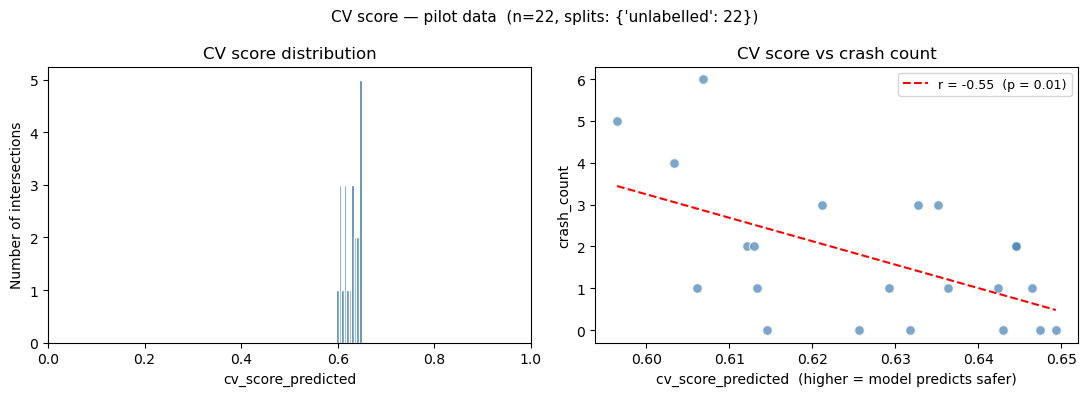

cv_score range  : [0.5965, 0.6494]
Pearson r       : -0.547  (p = 0.008)
Note: narrow score range in pilot data — signal may strengthen with full dataset.


In [8]:
# CV score distribution and its relationship with crash count.
# All pilot intersections are 'unlabelled' (no BT label); the scatter
# gives a first impression of the cv_score → crash_count signal.

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: histogram of CV scores
ax = axes[0]
ax.hist(df["cv_score_predicted"], bins=10, color="steelblue", edgecolor="white")
ax.set_xlabel("cv_score_predicted")
ax.set_ylabel("Number of intersections")
ax.set_title("CV score distribution")
ax.set_xlim(0, 1)   # show the full 0-1 model output range for context

# Right: scatter cv_score vs crash_count with linear trend
ax = axes[1]
ax.scatter(df["cv_score_predicted"], df["crash_count"],
           alpha=0.7, color="steelblue", s=50, edgecolors="white")
ax.set_xlabel("cv_score_predicted  (higher = model predicts safer)")
ax.set_ylabel("crash_count")
ax.set_title("CV score vs crash count")

# Pearson r and simple OLS line for visual reference only
slope, intercept, r_val, p_val, _ = stats.linregress(
    df["cv_score_predicted"], df["crash_count"]
)
x_line = np.linspace(df["cv_score_predicted"].min(), df["cv_score_predicted"].max(), 100)
ax.plot(x_line, slope * x_line + intercept, "r--",
        label=f"r = {r_val:.2f}  (p = {p_val:.2f})")
ax.legend(fontsize=9)

n_with_cv = df["cv_score_predicted"].notna().sum()
cv_split_summary = df["cv_split"].value_counts().to_dict()
plt.suptitle(
    f"CV score — pilot data  (n={n_with_cv}, splits: {cv_split_summary})",
    fontsize=11,
)
plt.tight_layout()
plt.savefig(PLOTS / "eda_cv_score.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"cv_score range  : [{df['cv_score_predicted'].min():.4f}, "
      f"{df['cv_score_predicted'].max():.4f}]")
print(f"Pearson r       : {r_val:.3f}  (p = {p_val:.3f})")
print("Note: narrow score range in pilot data — signal may strengthen with full dataset.")

## Handover

**Produced:** EDA plots in `outputs/diagnostic_plots/eda_*.png`

| Plot | File |
|------|------|
| Crash count distribution + Poisson overlay | `eda_crash_distribution.png` |
| Mean vs variance per stratum | `eda_mean_variance.png` |
| Predictor correlation matrix | `eda_correlation.png` |
| Crash count by dim_type and dim_priority | `eda_crash_by_category.png` |
| CV score distribution + scatter vs crash count | `eda_cv_score.png` |

**What NB03 expects:**
- `data/processed/nb_model_ready.csv` (same file, NB02 does not modify it)
- Confirmed overdispersion (variance >> mean) justifying NB over Poisson
- Column `cv_split_flagged` exists to exclude train/val rows from the NB model

**Written conclusion (fill in after running):**
- Overdispersion confirmed? → variance/mean = *[see Section 1 output]*
- Predictors most correlated with crash_count? → *[see Section 3 heatmap]*
- Collinearity concerns? → *[see Section 3 printed output]*
- CV score signal → crash_count? → *[see Section 5 Pearson r]*